# Thermodynamic analysis of cylinder pressure profile

### 1. Import packages and set input data

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ------------------------------------------------
# INPUT FILE
# ------------------------------------------------

folder_path = r"E:\Proj87-Universite_dOrleans_Ammonia-DME_Spark_Ignition\08-Experiments\01-Testbench_C8\01-Ammonia_DME\251009_1000rpm_Phi1i0_Tin45degC_DMEsweep_SparkTimingsweep\_python_results"
file_path = r"AR_MT_251009_15h40m08s_13696.txt"
emission_file = r"emission_output.txt"
performance_file = r"performance_output.txt"

# ------------------------------------------------
# UNIVERSAL PARAMETERS
# ------------------------------------------------

R = 287
Ru = 8.314462618

# ------------------------------------------------
# ENGINE PARAMETERS
# ------------------------------------------------

# geometry
bore = 0.085
stroke = 0.088
conrod = 0.145
compression_ratio = 14.23

# operating conditions
rpm = 1000
Spark_timing = -36
Twall = 450
IVC = -122
EVO = 149

# ------------------------------------------------
# STANDARD CONDITIONS
# ------------------------------------------------

# Pa
p_std = 101325

# K
T_std = 273.15

# ------------------------------------------------
# AIR COMPOSITION
# ------------------------------------------------

# mole fraction
x_N2 = 0.79
x_O2 = 0.21

# molar weights (kg/mol)
M_N2 = 28.0134e-3
M_O2 = 31.9988e-3

# ------------------------------------------------
# FUEL COMPOSITION
# ------------------------------------------------

# mole fraction
x_NH3 = 1.0
x_DME = 0.0

# molar weights (kg/mol)
M_NH3 = 17.03052e-3
M_DME = 46.06844e-3

# lower heating values (J/kg)
LHV_NH3 = 18.6e6
LHV_DME = 28.4e6
LHV_CO  = 10.1e6

# ------------------------------------------------
# WOSCHNI HEAT TRANSFER MODEL PARAMETERS
# ------------------------------------------------

C1 = 2.28
C2 = 0.00322

### 2. Read input files

In [33]:
# ------------------------------------------------
# READ PERFORMANCE DATA
# ------------------------------------------------

with open(folder_path + "\\" + "performance_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_air = header.index("Air[Nl/min]")
    idx_fuel_nh3 = header.index("NH3[Nl/min]")
    idx_fuel_dme = header.index("DME[Nl/min]")

    air_flow_Lmin = None
    nh3_flow_Lmin = None
    dme_flow_Lmin = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            air_flow_Lmin = float(parts[idx_air])
            nh3_flow_Lmin = float(parts[idx_fuel_nh3])
            dme_flow_Lmin = float(parts[idx_fuel_dme])

            break

# ------------------------------------------------
# READ EMISSION DATA
# ------------------------------------------------

with open(folder_path + "\\" + "emission_output.txt","r") as f:

    header = f.readline().strip().split()

    idx_CO = header.index("CO[vol-ppm]")
    idx_NH3 = header.index("NH3[vol-ppm]")
    idx_CH2O = header.index("CH2O[vol-ppm]")
    idx_CH3CHO = header.index("CH3CHO[vol-ppm]")

    X_CO_exhaust = None
    X_NH3_exhaust = None
    X_CH2O_exhaust = None
    X_CH3CHO_exhaust = None

    for line in f:

        parts = line.split()

        if float(parts[0]) == Spark_timing:

            X_CO_exhaust = float(parts[idx_CO])
            X_NH3_exhaust = float(parts[idx_NH3])
            X_CH2O_exhaust = float(parts[idx_CH2O])
            X_CH3CHO_exhaust = float(parts[idx_CH3CHO])

            break

# ------------------------------------------------
# CONVERT TO FRACTIONS
# ------------------------------------------------

X_CO_exhaust = X_CO_exhaust * 1e-6
X_NH3_exhaust = X_NH3_exhaust * 1e-6
X_CH2O_exhaust = X_CH2O_exhaust * 1e-6
X_CH3CHO_exhaust = X_CH3CHO_exhaust * 1e-6

# ------------------------------------------------
# SANITY CHECK FOR OXYGENATES
# ------------------------------------------------

if (X_CH2O_exhaust + X_CH3CHO_exhaust) > X_NH3_exhaust:

    print("The mole fraction of unburned oxygenates is too high")

    X_CH2O_exhaust = 0.0
    X_CH3CHO_exhaust = 0.0

# ------------------------------------------------
# LOAD PRESSURE TRACE
# ------------------------------------------------

file_prefix = file_path.replace(".txt", "")
data = pd.read_csv(folder_path + "\\" + file_path, sep='\s+')

theta = data["CAD[deg]"].values
p_cyl = data["p_cyl[bar]"].values*1e5
p_intake = data["p_intake[bar]"].values*1e5



### 3. Calculations

In [ ]:
# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

def cylinder_volume(theta):

    # deg -> rad
    th = np.radians(theta)

    # instantaneous stroke
    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return Vc + area*x

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

def cylinder_area(theta):

    # deg -> rad
    th = np.radians(theta)

    # instantaneous stroke
    x = r*(1-np.cos(th)) + (l - np.sqrt(l**2-(r*np.sin(th))**2))

    return 2*area + np.pi*bore*x

# ------------------------------------------------
# GAMMA FUNCTION
# ------------------------------------------------

def gamma_T(T):

    # correlation funtion
    g = 1.38 - 0.0001*(T-300)

    return np.clip(g,1.25,1.40)

# ------------------------------------------------
# EXTENDED WOSCHNI HEAT TRANSFER
# ------------------------------------------------

def woschni_ht(theta,area,p,T,V,p_mot,C0):

    B = bore
    Vd = Vs

    # mean piston speed (m/s)
    Cm = 2*stroke*rpm/60

    # initialize heat transfer rate vector
    Qdeg = np.zeros_like(theta)

    for i in range(len(theta)):

        # base gas velocity (m/s)
        w = C1 * Cm

        # combustion contribution only during combustion
        if Spark_timing <= theta[i] <= EVO:
            
            # pressure difference
            dp = max(p[i] - p_mot[i],0)
            w += C2 * (Vd * T[i] / (p[i] * V[i])) * dp

        # Woschni function
        h = C0 * (B**-0.2) * (p[i]/1000)**0.8 * (T[i]**-0.53) * (w**0.8)

        # heat transfer rate (J/s)
        Qdot = h * area[i] * (T[i] - Twall)

        # J/s -> J/deg
        Qdeg[i] = Qdot / (6*rpm)

    return Qdeg

# ------------------------------------------------
# OPTIMIZE C0
# ------------------------------------------------

def optimize_C0(theta,p,T,V,p_mot,HRR_app,comb_eff):

    # mask crank angle range between spark timing and EVO
    mask = (theta>=Spark_timing) & (theta<=EVO)

    # mask crank angle and heat release rate vectors
    theta_c = theta[mask]
    HRR_c = HRR_app[mask]

    # energy at EVO
    target_energy = LHV_fuel*fuel_mass_cycle*comb_eff

    # start values
    best_C0 = 3.26
    best_error = 1e30

    # optimize C0 between 0.5 and 30
    for C0 in np.linspace(0.5,30.0,600):

        # evaluate Woschni function
        Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

        # mask heat transfer rate
        Qw_c = Qw[mask]

        # cumulate heat release and heat transfer
        released = np.trapz(HRR_c,theta_c)
        heatloss = np.trapz(Qw_c,theta_c)

        # sum of heat release and heat transfer
        energy = released + heatloss

        # evaluate absolute error
        error = abs(energy-target_energy)

        if error < best_error:

            best_error = error
            best_C0 = C0

    print("Energy at EVO:",target_energy,"J")
    print("Error:",best_error,"J")
    print("Optimized C0:",best_C0)

    return best_C0

# ------------------------------------------------
# MOTORED PRESSURE FIT
# ------------------------------------------------

def calculate_motored_pressure(theta, p, V, IVC, Spark_timing):

    # determine IVC
    idx_ivc = np.argmin(np.abs(theta-IVC))

    # pressure and volume at IVC
    p_ivc = p[idx_ivc]
    V_ivc = V[idx_ivc]

    # define mask criteria
    mask = (theta >= IVC) & (theta <= Spark_timing)

    # motored pressure and volume
    p_fit = p[mask]
    V_fit = V[mask]

    # start values
    best_n = 1.3
    best_error = 1e30

    # search polytropic exponent
    for n in np.linspace(1.20,1.40,200):

        # determine motored pressure
        p_model = p_ivc*(V_ivc/V_fit)**n

        # evaluate squared error
        error = np.mean((p_fit-p_model)**2)

        if error < best_error:

            best_error = error
            best_n = n

    print("Best polytropic exponent:",best_n)

    # compute full motored curve
    p_mot = p_ivc*(V_ivc/V)**best_n

    return p_mot

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

def find_CA(target):
    idx = np.where(CHR_norm >= target)[0][0]
    return theta[idx]

# ------------------------------------------------
# AIR COMPOSITION
# ------------------------------------------------

M_air = x_N2*M_N2 + x_O2*M_O2

rho_air = p_std*M_air/(Ru*T_std)

# ------------------------------------------------
# FUEL COMPOSITION
# ------------------------------------------------

M_fuel = x_NH3*M_NH3 + x_DME*M_DME

# mass fractions

w_NH3 = x_NH3*M_NH3/M_fuel
w_DME = x_DME*M_DME/M_fuel

# lower heating values

LHV_fuel = w_NH3*LHV_NH3 + w_DME*LHV_DME

# fuel density at standard conditions

rho_fuel = p_std*M_fuel/(Ru*T_std)

print("Fuel molar mass:",M_fuel,"kg/mol")
print("Fuel LHV:",LHV_fuel/1e6,"MJ/kg")

# ------------------------------------------------
# VOLUME FLOW INPUT (L/min)
# ------------------------------------------------

fuel_flow_Lmin = nh3_flow_Lmin + dme_flow_Lmin

# ------------------------------------------------
# FLOW CONVERSION
# ------------------------------------------------

air_flow_m3s = air_flow_Lmin/1000/60
fuel_flow_m3s = fuel_flow_Lmin/1000/60

air_mdot = rho_air*air_flow_m3s
fuel_mdot = rho_fuel*fuel_flow_m3s

# ------------------------------------------------
# MASS PER ENGINE CYCLE
# ------------------------------------------------

rev_per_sec = rpm/60
cycles_per_sec = rev_per_sec/2

air_mass_cycle = air_mdot/cycles_per_sec
fuel_mass_cycle = fuel_mdot/cycles_per_sec

m_total = air_mass_cycle + fuel_mass_cycle

fuel_energy = fuel_mass_cycle*LHV_fuel

print("Air mass per cycle:",air_mass_cycle,"kg")
print("Fuel mass per cycle:",fuel_mass_cycle,"kg")
print("Fuel energy per cycle:",fuel_energy,"J")

# ------------------------------------------------
# GEOMETRY
# ------------------------------------------------

area = np.pi*(bore/2)**2
r = stroke/2
l = conrod

Vs = area*stroke
Vc = Vs/(compression_ratio-1)

# ------------------------------------------------
# PRESSURE PEGGING
# ------------------------------------------------

# define mask criteria
mask = (theta>-180)&(theta<IVC)

# calculate pressure offset
offset = np.mean(p_intake[mask]) - np.mean(p_cyl[mask])

# peg cylinder pressure
p = p_cyl + offset

print("Pressure offset:", offset/1e5, "bar")

# ------------------------------------------------
# FILTER PRESSURE
# ------------------------------------------------

p = savgol_filter(p,21,3)

# ------------------------------------------------
# CYLINDER VOLUME
# ------------------------------------------------

V = cylinder_volume(theta)

# ------------------------------------------------
# CYLINDER AREA
# ------------------------------------------------

A = cylinder_area(theta)

# ------------------------------------------------
# TEMPERATURE AT IVC
# ------------------------------------------------

# determine IVC
idx = np.argmin(np.abs(theta-IVC))

# calculate temperature according to ideal gas law
T_ivc = p[idx]*V[idx]/(m_total*R)

print("Temperature at IVC:",T_ivc,"K")

# ------------------------------------------------
# MOTORED PRESSURE
# ------------------------------------------------

p_mot = calculate_motored_pressure(theta,p,V,IVC,Spark_timing)

# ------------------------------------------------
# ITERATIVE HEAT RELEASE SOLVER
# ------------------------------------------------

gamma = np.ones(len(theta))*1.35

for i in range(5):

    # pressure gradient
    dp = np.gradient(p,theta)
    # volume gradient
    dV = np.gradient(V,theta)

    # apparent rate of heat release
    HRR_app = (gamma/(gamma-1))*p*dV + (1/(gamma-1))*V*dp

    # temperature
    T = p*V/(m_total*R)

    # heat capacity ratio
    gamma = gamma_T(T)

# ------------------------------------------------
# IMEP
# ------------------------------------------------

# work
work = np.trapz(p, V)

# IMEP
IMEP = work / Vs

print("IMEP:", IMEP/1e5, "bar")

# ------------------------------------------------
# Thermal efficiency
# ------------------------------------------------

eta_therm = (IMEP*Vs)/(LHV_fuel*fuel_mass_cycle)*100

print("Thermal efficiency:",eta_therm,"%")

# ------------------------------------------------
# COMBUSTION EFFICIENCY
# ------------------------------------------------

# energy of CO
loss_CO = X_CO_exhaust * LHV_CO

# energy of unburned NH3
loss_NH3 = X_NH3_exhaust * LHV_NH3

# energy of oxygenated hydrocarbons
loss_oxygenates = (X_CH2O_exhaust + X_CH3CHO_exhaust) * LHV_DME

# energy of exhaust
chemical_loss = loss_CO + loss_NH3 + loss_oxygenates

# combustion efficiency
combustion_efficiency = 1 - chemical_loss / LHV_fuel

print("Combustion efficiency:", combustion_efficiency)

# ------------------------------------------------
# OPTIMIZE HEAT TRANSFER PARAMETER
# ------------------------------------------------

C0 = optimize_C0(theta,p,T,V,p_mot,HRR_app,combustion_efficiency)

# compute final heat transfer
Qw = woschni_ht(theta,A,p,T,V,p_mot,C0)

# ------------------------------------------------
# TOTAL HEAT RELEASE RATE
# ------------------------------------------------

HRR_total = HRR_app + Qw

# ------------------------------------------------
# CUMULATED HEAT RELEASE
# ------------------------------------------------

# cumulated heat release
CHR = np.cumsum(HRR_app*np.gradient(theta))

# normalize cumulated heat release
CHR_norm = (CHR - np.min(CHR)) / (np.max(CHR) - np.min(CHR))

# cumulated heat release
CHR_total = np.cumsum(HRR_total*np.gradient(theta))

# cumulated heat transfer
CQw = np.cumsum(Qw*np.gradient(theta))

# ------------------------------------------------
# COMBUSTION PHASING
# ------------------------------------------------

CA10 = find_CA(0.10)
CA50 = find_CA(0.50)
CA90 = find_CA(0.90)
print("CA10 =", CA10, "deg")
print("CA50 =", CA50, "deg")
print("CA90 =", CA90, "deg")


Fuel molar mass: 0.01703052 kg/mol
Fuel LHV: 18.6 MJ/kg
Air mass per cycle: 0.0003700683991368225 kg
Fuel mass per cycle: 6.130813174460659e-05 kg
Fuel energy per cycle: 1140.3312504496826 J
Pressure offset: -0.055522003454231306 bar
Temperature at IVC: 394.80592533599304 K
Best polytropic exponent: 1.3969849246231156
IMEP: 6.538891912714314 bar
Thermal efficiency: 28.634099999216488 %
Combustion efficiency: 0.9928418313384946
700.9445031941976 1132.1685670289783 431.2240638347806 1e+30 0.5
703.7596430664938 1132.1685670289783 428.40892396248444 431.2240638347806 0.5492487479131887
706.57478293879 1132.1685670289783 425.59378409018825 428.40892396248444 0.5984974958263773
709.3899228110863 1132.1685670289783 422.77864421789195 425.59378409018825 0.6477462437395659
712.2050626833825 1132.1685670289783 419.96350434559577 422.77864421789195 0.6969949916527546
715.0202025556787 1132.1685670289783 417.1483644732996 419.96350434559577 0.7462437395659433
717.8353424279749 1132.1685670289783 4

### 4. save the results

In [38]:
# ------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------

out = np.column_stack([

theta,
p,
p_mot,
gamma,
T,
HRR_app,
HRR_total,
Qw,
CHR,
CHR_total,
CQw,
CHR_norm

])

header = "CAD[deg]\tp_filtered[bar]\tp_motored[bar]\tgamma[-]\tT[K]\tHRR_app[J/deg]\tHRR_total[J/deg]\tQw[J/deg]\tCHR_app[J]\tCHR_total[J]\tCQw[J]\tBurn_rate[-]"

np.savetxt(folder_path + "\\" + file_prefix + "_thermo_results.txt",out,header=header,comments='',delimiter='\t')

out = np.column_stack([

LHV_fuel,
fuel_energy,
air_mass_cycle,
fuel_mass_cycle,
T_ivc,
IMEP,
eta_therm,
combustion_efficiency,
CA10,
CA50,
CA90

])

header = "LHV_fuel[J/kg]\tFuel_energy[J]\tAir_mass_cycle[kg]\tFuel_mass_cycle[kg]\tT_IVC[K]\tIMEP[bar]\teta_therm[%]\tcomb_eff[-]\tCA10[deg]\tCA50[deg]\tCA90[deg]"

np.savetxt(folder_path + "\\" + file_prefix + "_global_results.txt",out,header=header,comments='',delimiter='\t')

print("Results written to global_results.txt")

Results written to global_results.txt


### 5. plot the results

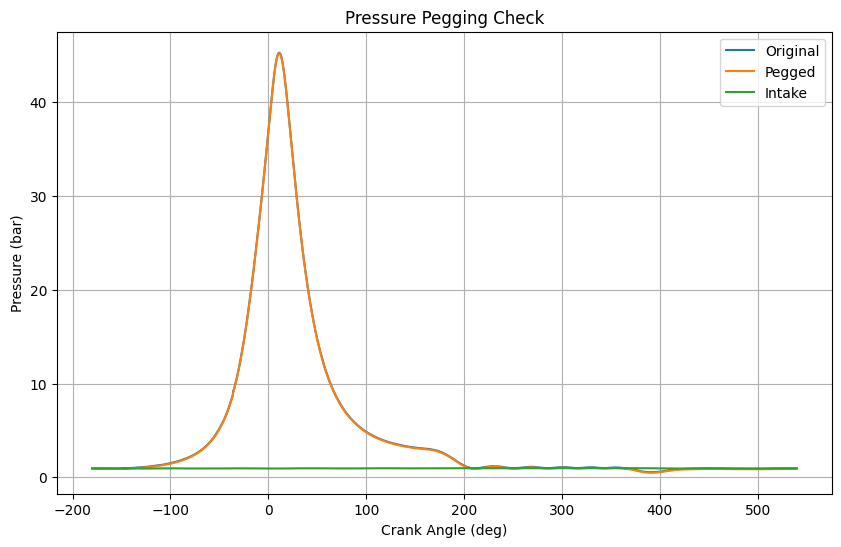

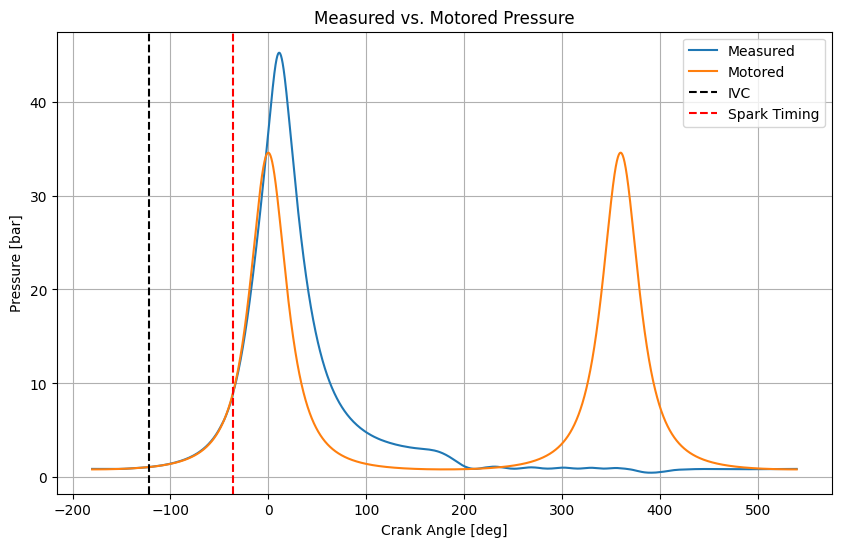

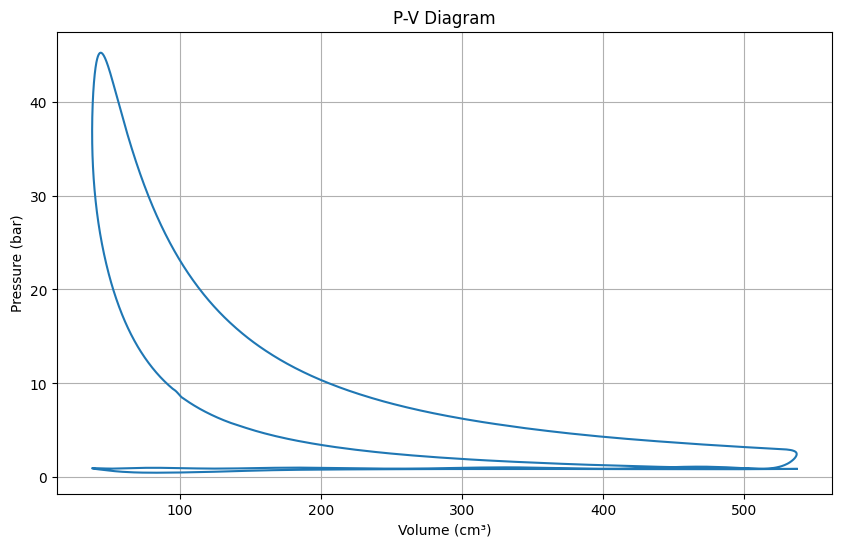

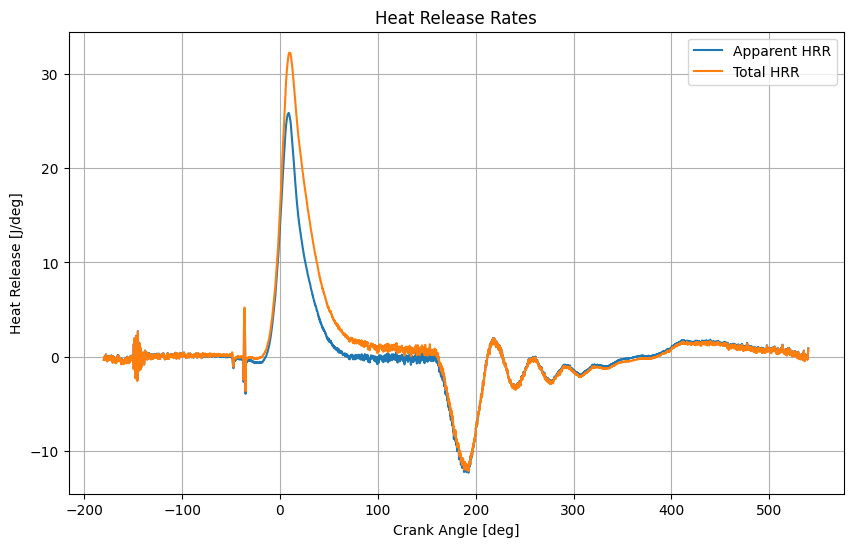

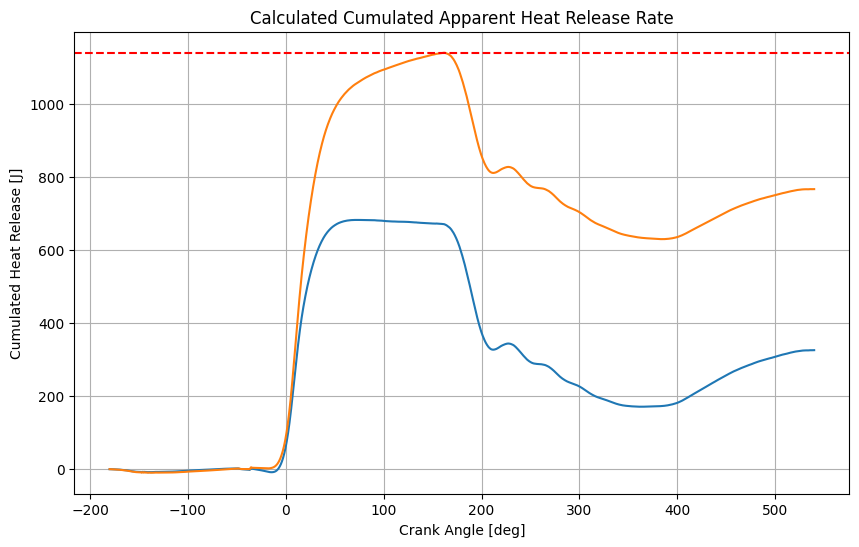

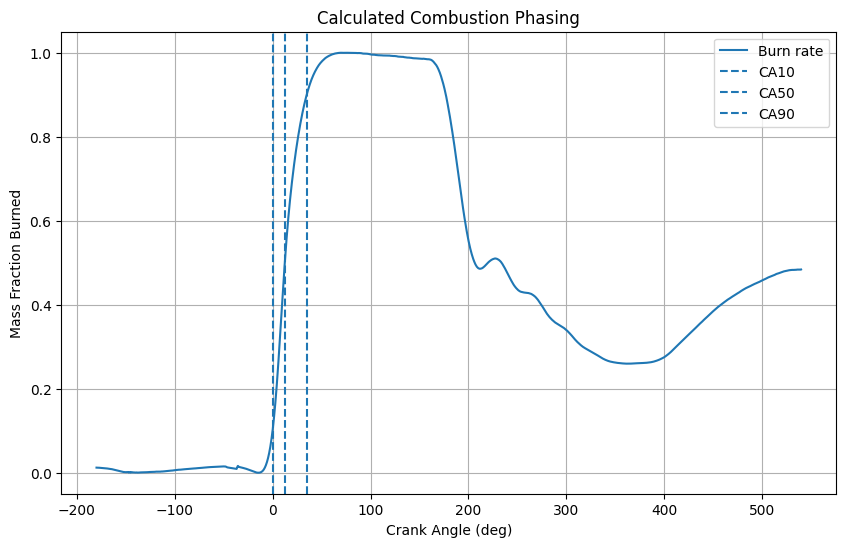

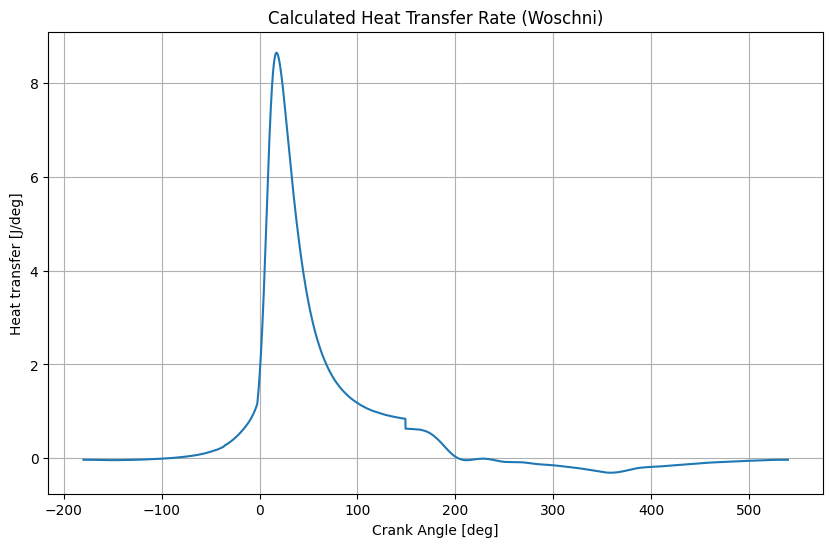

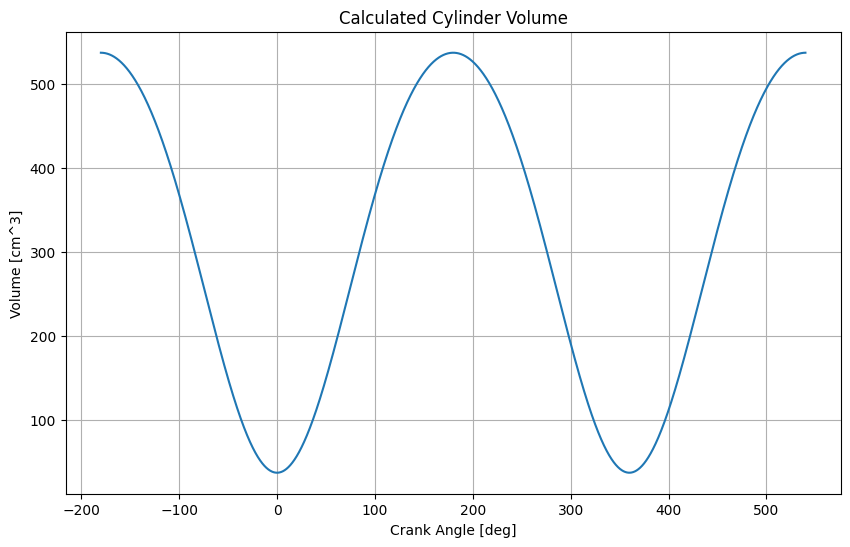

In [37]:
# ------------------------------------------------
# PLOTS
# ------------------------------------------------

# Original, pegged cylinder and intake manifold pressure profiles
plt.figure(figsize=(10,6))
plt.plot(theta, p_cyl/1e5, label="Original")
plt.plot(theta, p/1e5, label="Pegged")
plt.plot(theta, p_intake/1e5, label="Intake")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Pressure (bar)")
plt.title("Pressure Pegging Check")
plt.legend()
plt.grid()
plt.show()

# Measured and calculated motored pressure
plt.figure(figsize=(10,6))
plt.plot(theta,p/1e5,label="Measured")
plt.plot(theta,p_mot/1e5,label="Motored")
plt.axvline(IVC, linestyle="--", color="black", label="IVC")
plt.axvline(Spark_timing, linestyle="--", color="red", label="Spark Timing")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Pressure [bar]")
plt.title("Measured vs. Motored Pressure")
plt.legend()
plt.grid()
plt.show()

# p-V diagram
plt.figure(figsize=(10,6))
plt.plot(V*1e6, p/1e5)
plt.xlabel("Volume (cm³)")
plt.ylabel("Pressure (bar)")
plt.title("P-V Diagram")
plt.grid()
plt.show()

# Apparent and total heat release rate
plt.figure(figsize=(10,6))
plt.plot(theta,HRR_app,label="Apparent HRR")
plt.plot(theta,HRR_total,label="Total HRR")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat Release [J/deg]")
plt.title("Heat Release Rates")
plt.legend()
plt.grid()
plt.show()

# Cumulated heat release
plt.figure(figsize=(10,6))
plt.plot(theta,CHR,label="Cumulated Apparent HR")
plt.plot(theta,CHR_total,label="Cumulated Total HR")
plt.axhline(LHV_fuel*fuel_mass_cycle, linestyle="--", color="red", label="Fuel energy")
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Cumulated Heat Release [J]")
plt.title("Calculated Cumulated Apparent Heat Release Rate")
plt.grid()
plt.show()

# Burn rate and combustion phasing
plt.figure(figsize=(10,6))
plt.plot(theta, CHR_norm, label="Burn rate")
plt.axvline(CA10, linestyle="--", label="CA10")
plt.axvline(CA50, linestyle="--", label="CA50")
plt.axvline(CA90, linestyle="--", label="CA90")
plt.xlabel("Crank Angle (deg)")
plt.ylabel("Mass Fraction Burned")
plt.title("Calculated Combustion Phasing")
plt.legend()
plt.grid()
plt.show()

# Heat transfer rate
plt.figure(figsize=(10,6))
plt.plot(theta,Qw)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Heat transfer [J/deg]")
plt.title("Calculated Heat Transfer Rate (Woschni)")
plt.grid()
plt.show()

# Volume
plt.figure(figsize=(10,6))
plt.plot(theta,V*1e6)
plt.xlabel("Crank Angle [deg]")
plt.ylabel("Volume [cm^3]")
plt.title("Calculated Cylinder Volume")
plt.grid()
plt.show()